In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, EfficientFrontier, expected_returns
import pandas as pd
import joblib  # For saving and loading scalers
import matplotlib.pyplot as plt  # For plotting
from tensorflow.keras.models import Sequential, load_model
import warnings
warnings.filterwarnings("ignore")

In [2]:
risk_free_rate = 0.06  # Risk free rate

In [3]:
data = pd.read_csv("Top_4_stocks.csv")
data["Date"] = pd.to_datetime(data['Date'])
data.set_index("Date", inplace=True)
data.head(10)

,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2015-01-01,440.343475,386.326385,185.691818,1032.979614
2015-01-02,446.471832,393.918243,185.200363,1046.735840
2015-01-05,442.702271,390.533234,183.171738,1030.828857
2015-01-06,435.810760,382.373810,174.858582,992.825623
2015-01-07,437.082672,384.203430,178.664856,981.098083
2015-01-08,446.263672,386.140472,176.102951,991.689270
2015-01-09,451.258942,405.902893,179.919662,1019.487000
2015-01-12,447.281219,414.023071,177.828308,1018.431702
2015-01-13,445.569885,408.730286,176.332993,1013.643127


In [4]:
assets = data.columns
assets

Index(['HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS'], dtype='object')

In [5]:
import datetime
def get_market_cap_on_date(ticker_symbol, date_str):
    stock = yf.Ticker(ticker_symbol)
    # date = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
    hist = stock.history(start=date_str, end = (date + datetime.timedelta(days=1)).strftime("%Y-%m-%d"))
    if hist.empty:
        return f"No data available for {ticker_symbol} on {date_str}" 
    closing_price = hist["Close"].iloc[0]  # Get closing price on the given date
    shares_outstanding = stock.info.get("sharesOutstanding", None)
    if shares_outstanding is None:
        return None
    market_cap = closing_price * shares_outstanding
    return market_cap


def annualize_returns(returns, horizon=5):
    trading_days_per_year = 252
    annualized_returns = (1 + returns) ** (trading_days_per_year / horizon) - 1
    return annualized_returns

In [6]:
date = data.index[400]
for asset in assets:
    print(f"{asset}: {get_market_cap_on_date(asset, date)}")

HDFCBANK.NS: 4439509120492.531
INFY.NS: 1721673632919.9219
RELIANCE.NS: 2950007777495.625
TCS.NS: 4053026622904.25


In [8]:
mcaps = {ticker: get_market_cap_on_date(ticker, date) for ticker in assets}
mcaps = pd.Series(mcaps)

In [9]:
initial_weights = mcaps / mcaps.sum()
initial_weights

HDFCBANK.NS    0.337241
INFY.NS        0.130784
RELIANCE.NS    0.224093
TCS.NS         0.307882
dtype: float64

In [10]:
training_dates = []
testing_dates = []

start_date = data.index[0 + 5]
end_date = data.index[-1]

# Generate training and testing date ranges
while start_date + pd.DateOffset(years=4) <= end_date:
    training_dates.append((start_date, start_date + pd.DateOffset(years=3)))
    testing_dates.append((start_date + pd.DateOffset(years=3), start_date + pd.DateOffset(years=4)))
    start_date += pd.DateOffset(years=1)

In [11]:
training_dates, testing_dates

([(Timestamp('2015-01-08 00:00:00'), Timestamp('2018-01-08 00:00:00')),
  (Timestamp('2016-01-08 00:00:00'), Timestamp('2019-01-08 00:00:00')),
  (Timestamp('2017-01-08 00:00:00'), Timestamp('2020-01-08 00:00:00')),
  (Timestamp('2018-01-08 00:00:00'), Timestamp('2021-01-08 00:00:00')),
  (Timestamp('2019-01-08 00:00:00'), Timestamp('2022-01-08 00:00:00')),
  (Timestamp('2020-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00')),
  (Timestamp('2021-01-08 00:00:00'), Timestamp('2024-01-08 00:00:00'))],
 [(Timestamp('2018-01-08 00:00:00'), Timestamp('2019-01-08 00:00:00')),
  (Timestamp('2019-01-08 00:00:00'), Timestamp('2020-01-08 00:00:00')),
  (Timestamp('2020-01-08 00:00:00'), Timestamp('2021-01-08 00:00:00')),
  (Timestamp('2021-01-08 00:00:00'), Timestamp('2022-01-08 00:00:00')),
  (Timestamp('2022-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00')),
  (Timestamp('2023-01-08 00:00:00'), Timestamp('2024-01-08 00:00:00')),
  (Timestamp('2024-01-08 00:00:00'), Timestamp('2025-01-08 00:0

In [12]:
t1 = pd.Timestamp("2024-03-11 10:30:00")
t2 = pd.Timestamp("2025-03-18 15:45:00")

def get_model_name(stock_name, idx):
    model_name = f"{stock_name}_{training_dates[idx][0].strftime('%Y%m%d')}_{training_dates[idx][1].strftime('%Y%m%d')}"
    print(model_name)
    return model_name

get_model_name(assets[1],0)

INFY.NS_20150108_20180108


'INFY.NS_20150108_20180108'

In [13]:
[d[1] for d in testing_dates]

[Timestamp('2019-01-08 00:00:00'),
 Timestamp('2020-01-08 00:00:00'),
 Timestamp('2021-01-08 00:00:00'),
 Timestamp('2022-01-08 00:00:00'),
 Timestamp('2023-01-08 00:00:00'),
 Timestamp('2024-01-08 00:00:00'),
 Timestamp('2025-01-08 00:00:00')]

In [19]:
# Backtest start and end dates
start_date = pd.to_datetime("2018-01-08")
end_date = pd.to_datetime("2025-01-08")

initial_weights = mcaps / mcaps.sum()  # Market-cap weights (Needs to be adjusted based on data)
initial_investment = 100  # Initial portfolio value
portfolio_value = [initial_investment]
dates = [start_date]

model_change_dates = [d[1] for d in testing_dates]  # All the dates when the model changes
model_number = 0

# Rebalancing frequency (e.g., every 5 days)
rebalance_frequency = 5

# Initial model for each asset
model_dict = {}
for asset in assets:
    model_name = get_model_name(asset, model_number)
    model = load_model(f"models/{model_name}.h5")
    scaler = joblib.load(f"models/{model_name}_scaler.pkl")
    model_dict[asset] = [model, scaler]

HDFCBANK.NS_20150108_20180108
INFY.NS_20150108_20180108
RELIANCE.NS_20150108_20180108
TCS.NS_20150108_20180108


In [20]:
# List to store weights
W = []

# Backtest loop
current_date = start_date
last_rebalance_date = start_date
previous_weights = None

while current_date < end_date:
    # Prepare input data for LSTM predictions
    Q = {}
    for stock_name, (model, scaler) in model_dict.items():
        input_data = data.loc[:current_date, stock_name].tail(30).values.reshape(-1, 1)
        scaled_input_data = scaler.transform(input_data)
        
        # Predict 5-day returns using the LSTM model
        scaled_predicted_returns = model.predict(scaled_input_data.reshape(1, 30, 1), verbose=0)
        predicted_returns = scaler.inverse_transform(scaled_predicted_returns)[0]
        
        # Annualize the predicted returns
        predicted_returns = annualize_returns(predicted_returns[0], horizon=5)
        Q[stock_name] = predicted_returns

    # View dictionary for Black-Litterman
    viewdict = Q

    # Covariance matrix (S)
    S = risk_models.sample_cov(data.loc[:current_date])

    # Risk aversion parameter
    delta = 1

    # Market-implied prior returns
    prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)

    # Black-Litterman model
    bl = BlackLittermanModel(S, pi=prior, absolute_views=viewdict)
    bl_returns = bl.bl_returns()

    # Efficient Frontier optimization
    ef = EfficientFrontier(bl_returns, S)
    ef.min_volatility()
    cleaned_weights = ef.clean_weights()

    # Check rebalancing conditions
    should_rebalance = False
    days_since_rebalance = (current_date - last_rebalance_date).days
    
    # Condition 1: Every 5 days
    if days_since_rebalance >= 5:
        should_rebalance = True
    
    # Condition 2: Weights change by 60% or more
    if previous_weights is not None:
        weight_diff = sum(abs(cleaned_weights.get(stock, 0) - previous_weights.get(stock, 0)) 
                         for stock in set(cleaned_weights.keys()) | set(previous_weights.keys()))
        if weight_diff >= 0.6:  # 60% threshold
            should_rebalance = True

    if should_rebalance:
        W.append(cleaned_weights)
        previous_weights = cleaned_weights.copy()
        last_rebalance_date = current_date
        
        # Compute portfolio returns for the next rebalance period
        curr_date_index = data.index.get_loc(current_date)
        next_index = min(curr_date_index + rebalance_frequency, len(data) - 1)
        next_date = data.index[next_index]

        # Get actual returns for the rebalance period
        actual_returns = data.loc[current_date:next_date].pct_change().dropna()

        # Ensure cleaned_weights is aligned correctly
        cleaned_weights_series = pd.Series(cleaned_weights)
        
        # Compute portfolio return
        portfolio_returns = (actual_returns @ cleaned_weights_series).values

        # Ensure equal length between portfolio_value and dates
        for j in range(len(portfolio_returns)):
            new_value = portfolio_value[-1] * (1 + portfolio_returns[j])
            portfolio_value.append(new_value)
            dates.append(actual_returns.index[j])  # Append correct date

        print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
        
        # Move to the next rebalance date
        current_date = next_date
    else:
        # Move forward one day if no rebalancing
        curr_date_index = data.index.get_loc(current_date)
        current_date = data.index[min(curr_date_index + 1, len(data) - 1)]

    # Model change logic
    if model_number < len(model_change_dates) and current_date >= model_change_dates[model_number]:
        model_number += 1
        try:
            for asset in assets:
                model_name = get_model_name(asset, model_number)
                model = load_model(f"models/{model_name}.h5")
                scaler = joblib.load(f"models/{model_name}_scaler.pkl")
                model_dict[asset] = [model, scaler]
        except Exception as e:
            print(f"Error loading new model: {e}")
            break

# Final portfolio value
print(f"Final portfolio value: {portfolio_value[-1]}")

Portfolio value at 2018-01-22 00:00:00: 106.01785019281905
Portfolio value at 2018-01-30 00:00:00: 107.1892197960715
Portfolio value at 2018-02-06 00:00:00: 101.69700870887593
Portfolio value at 2018-02-14 00:00:00: 101.14272439214011
Portfolio value at 2018-02-21 00:00:00: 101.94089449206409
Portfolio value at 2018-02-28 00:00:00: 103.32632598799677
Portfolio value at 2018-03-08 00:00:00: 101.44049910737827
Portfolio value at 2018-03-15 00:00:00: 101.58841879321085
Portfolio value at 2018-03-22 00:00:00: 100.634889931731
Portfolio value at 2018-04-02 00:00:00: 102.51706222000774
Portfolio value at 2018-04-09 00:00:00: 102.83239801734629
Portfolio value at 2018-04-16 00:00:00: 105.45158132959175
Portfolio value at 2018-04-23 00:00:00: 107.50412660312755
Portfolio value at 2018-04-30 00:00:00: 109.13961453889203
Portfolio value at 2018-05-08 00:00:00: 108.86470143759553
Portfolio value at 2018-05-15 00:00:00: 111.74438421755677
Portfolio value at 2018-05-22 00:00:00: 109.73107318203587


In [90]:
# dates = data[pd.to_datetime("2018-01-01"):].index
# dates

In [21]:
len(portfolio_value), len(dates)

(1726, 1726)

In [88]:
# historical_data = data.loc[:current_date].pct_change().dropna()
# S = risk_models.sample_cov(historical_data)  
# S.shape, Q

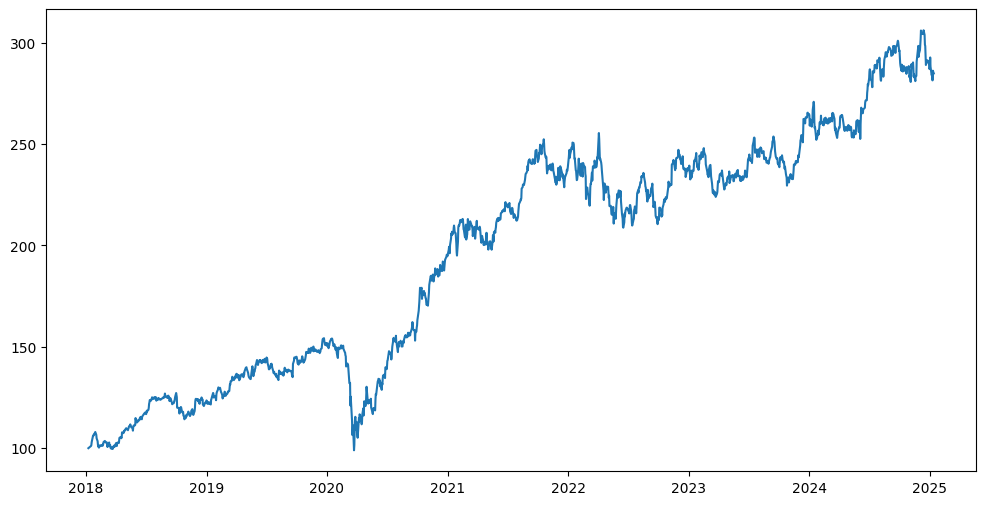

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(dates,portfolio_value, label='Portfolio Value')

In [23]:
len(W), len(portfolio_value), len(dates)

(345, 1726, 1726)

In [24]:
def get_annualized_returns(portfolio_value):
    return (portfolio_value[-1] / portfolio_value[0]) ** (252 / len(portfolio_value)) - 1

def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown

def get_volatility(portfolio_value):
    return portfolio_value.pct_change().std() * np.sqrt(252)

In [25]:
print(get_sharpe_ratio(pd.Series(portfolio_value)))
print(get_sortino_ratio(pd.Series(portfolio_value)))
print(get_volatility(pd.Series(portfolio_value)))
print(get_annualized_returns(portfolio_value))

0.5555104102725575
0.7151896284053078
0.18926285049407793
0.16513748372731896


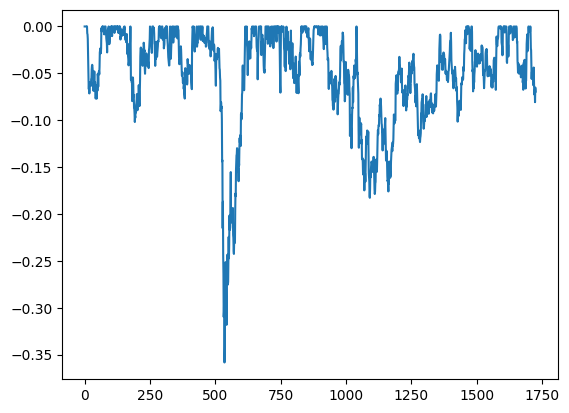

In [26]:
plt.plot(get_max_drawdown(portfolio_value), label="Equal Weights")

In [139]:
# plot tsla
# W

In [27]:
df = pd.DataFrame(W, index=dates[::5][:-1])

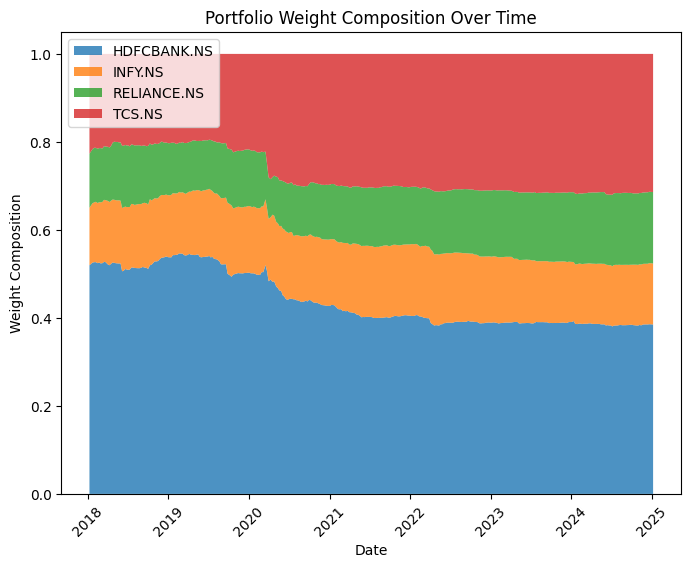

In [28]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(8, 6))
ax.stackplot(df.index, df.T, labels=df.columns, alpha=0.8)

# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # Format dates
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Show every month
plt.xticks(rotation=45)
plt.ylabel("Weight Composition")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.title("Portfolio Weight Composition Over Time")

plt.show()

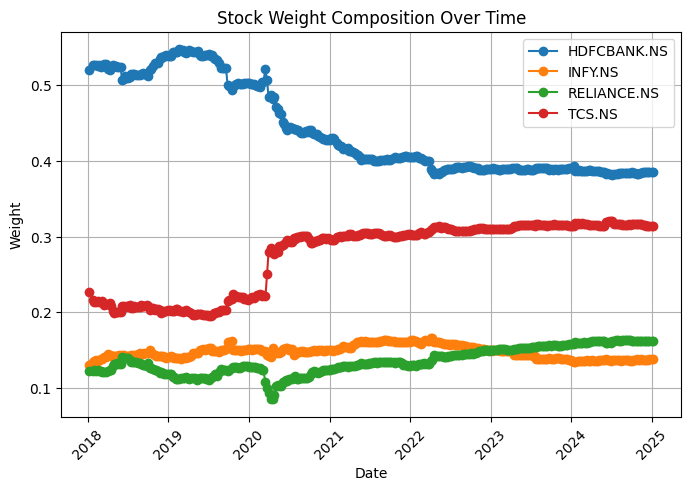

In [29]:
plt.figure(figsize=(8, 5))
for column in df.columns:
    plt.plot(df.index, df[column], marker="o", linestyle="-", label=column)

# Formatting
plt.xlabel("Date")
plt.ylabel("Weight")
plt.title("Stock Weight Composition Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [32]:
import pandas as pd

# Read and prepare data
nifty50 = pd.read_csv("NIFTY_50_Index.csv")
nifty50["Date"] = pd.to_datetime(nifty50["Date"])
nifty50.set_index("Date", inplace=True)

# Filter date range first
nifty50 = nifty50.loc["2018-01-08":"2025-01-08"]
nifty50_dates = nifty50["2018-01-08":"2025-01-08"].index

# Calculate returns on specific column
nifty50_returns = nifty50['^NSEI'].pct_change().dropna()

# Initialize portfolio
nifty50_portfolio = [100]

# Calculate portfolio value
for i in range(len(nifty50_returns)):
    nifty50_portfolio.append(nifty50_portfolio[-1] * (1 + nifty50_returns.iloc[i]))


In [33]:
len(nifty50_portfolio), len(nifty50_dates)

(1725, 1725)

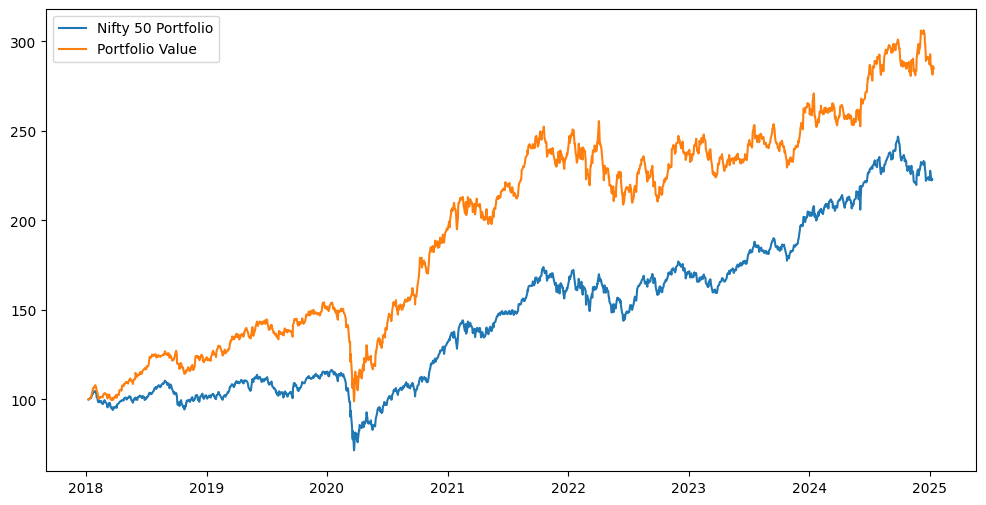

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(nifty50_dates, nifty50_portfolio, label='Nifty 50 Portfolio')
plt.plot(dates, portfolio_value, label='Portfolio Value')
plt.legend()

In [35]:
# make a dataframe for metrics
metrics = pd.DataFrame(columns=["Sharpe Ratio", "Sortino Ratio", "Volatility"], index=["BL Portfolio", "Nifty 50 Portfolio"])

# Calculate metrics
metrics.loc["BL Portfolio", "Sharpe Ratio"] = get_sharpe_ratio(pd.Series(portfolio_value))
metrics.loc["BL Portfolio", "Sortino Ratio"] = get_sortino_ratio(pd.Series(portfolio_value))
metrics.loc["BL Portfolio", "Volatility"] = get_volatility(pd.Series(portfolio_value))
metrics.loc["BL Portfolio", "Annualized Returns"] = get_annualized_returns(portfolio_value)
metrics.loc["BL Portfolio", "Max Drawdown"] = min(get_max_drawdown(pd.Series(portfolio_value)))

metrics.loc["Nifty 50 Portfolio", "Sharpe Ratio"] = get_sharpe_ratio(pd.Series(nifty50_portfolio))
metrics.loc["Nifty 50 Portfolio", "Sortino Ratio"] = get_sortino_ratio(pd.Series(nifty50_portfolio))
metrics.loc["Nifty 50 Portfolio", "Volatility"] = get_volatility(pd.Series(nifty50_portfolio))
metrics.loc["Nifty 50 Portfolio", "Annualized Returns"] = get_annualized_returns(nifty50_portfolio)
metrics.loc["Nifty 50 Portfolio", "Max Drawdown"] = min(get_max_drawdown(pd.Series(nifty50_portfolio)))

metrics

,Sharpe Ratio,Sortino Ratio,Volatility,Annualized Returns,Max Drawdown
BL Portfolio,0.55551,0.71519,0.189263,0.165137,-0.358406
Nifty 50 Portfolio,0.363193,0.430397,0.177013,0.124290,-0.384399


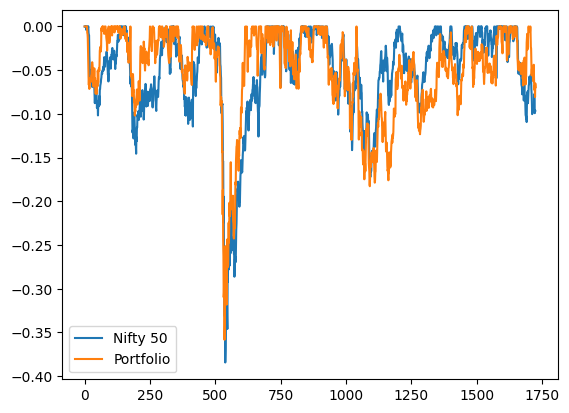

In [36]:
plt.plot(get_max_drawdown(nifty50_portfolio), label="Nifty 50")
plt.plot(get_max_drawdown(portfolio_value), label="Portfolio")
plt.legend()